In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')


In [4]:
conn = sqlite3.connect('inventory.db')
df = pd.read_sql_query("select *  from vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10756.0,1.064325e+04,18792.512136,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10756.0,1.802448e+04,12700.566640,58.00,5740.750000,18742.500000,25509.250000,9.063100e+04
PurchasePrice,10756.0,2.432476e+01,108.949251,0.36,6.840000,10.520000,19.470000,5.681810e+03
ActualPrice,10756.0,3.555612e+01,147.812478,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10756.0,8.466346e+02,663.018277,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10756.0,3.136392e+03,11068.301869,1.00,36.000000,263.000000,1978.500000,3.376600e+05
TotalPurchaseDollars,10756.0,3.006739e+04,122767.863224,0.71,454.530000,3669.780000,20724.510000,3.811252e+06
TotalSalesQuantity,10756.0,3.073020e+03,10926.159060,0.00,33.000000,262.500000,1931.000000,3.349390e+05
TotalSalesDollars,10756.0,4.217714e+04,167242.385324,0.00,729.270000,5310.485000,28396.915000,5.101920e+06
TotalSalesPrice,10756.0,1.877998e+04,44868.818270,0.00,289.717500,2867.075000,16095.092500,6.728193e+05


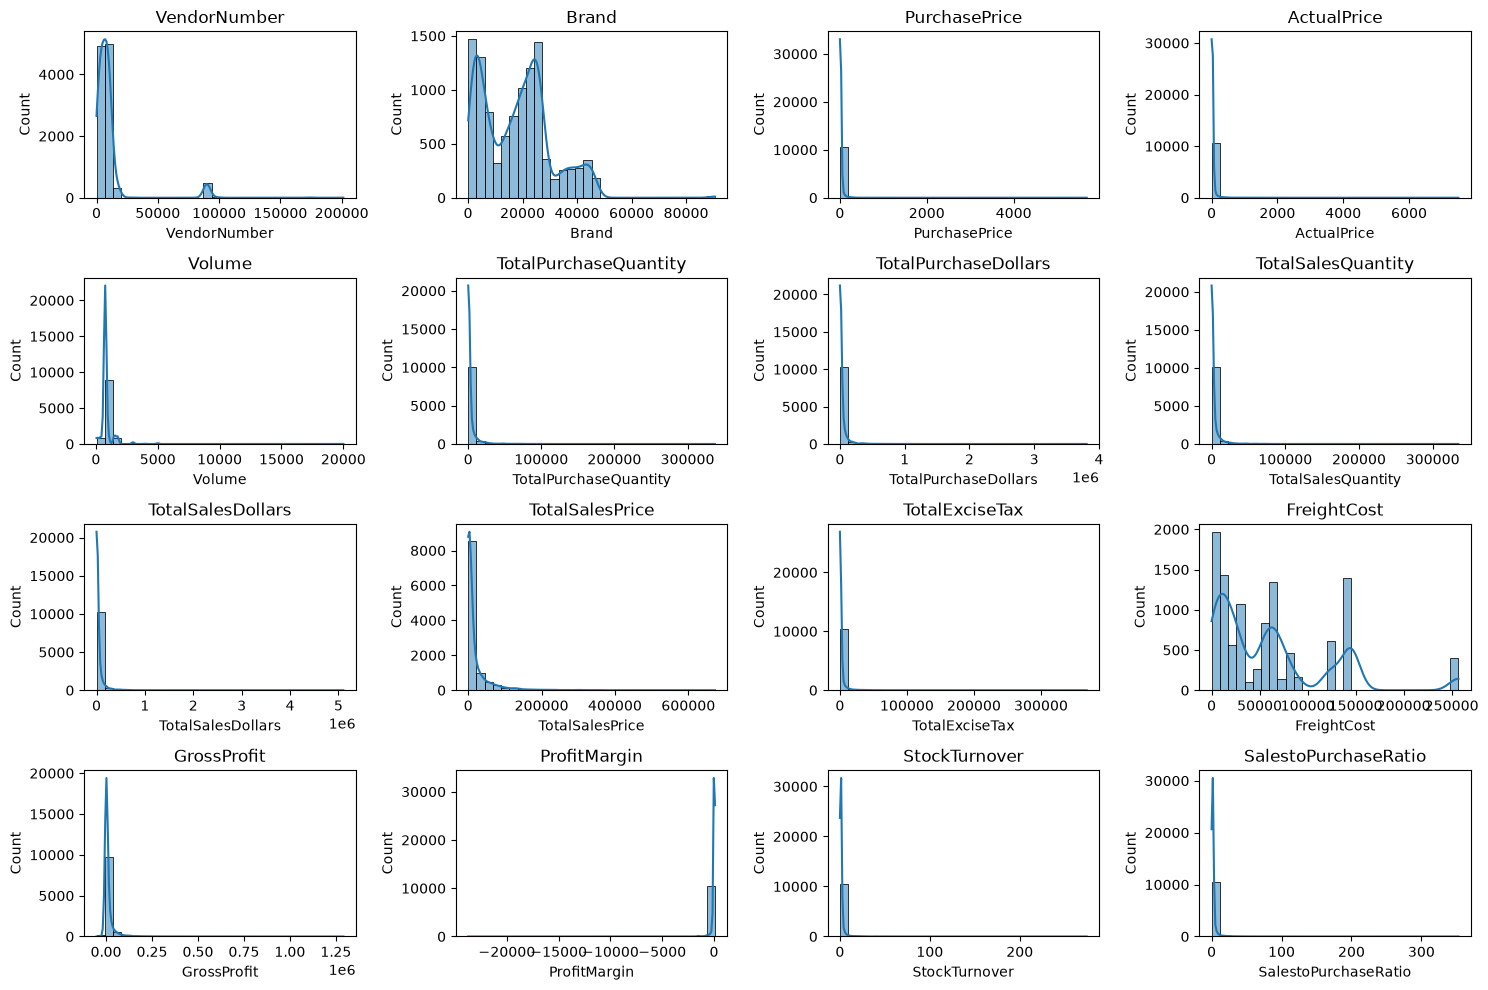

In [6]:

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
     plt.subplot(4, 4, i+1) 
     sns.histplot(df[col], kde=True, bins=30)
     plt.title(col)
plt.tight_layout()
plt.show()

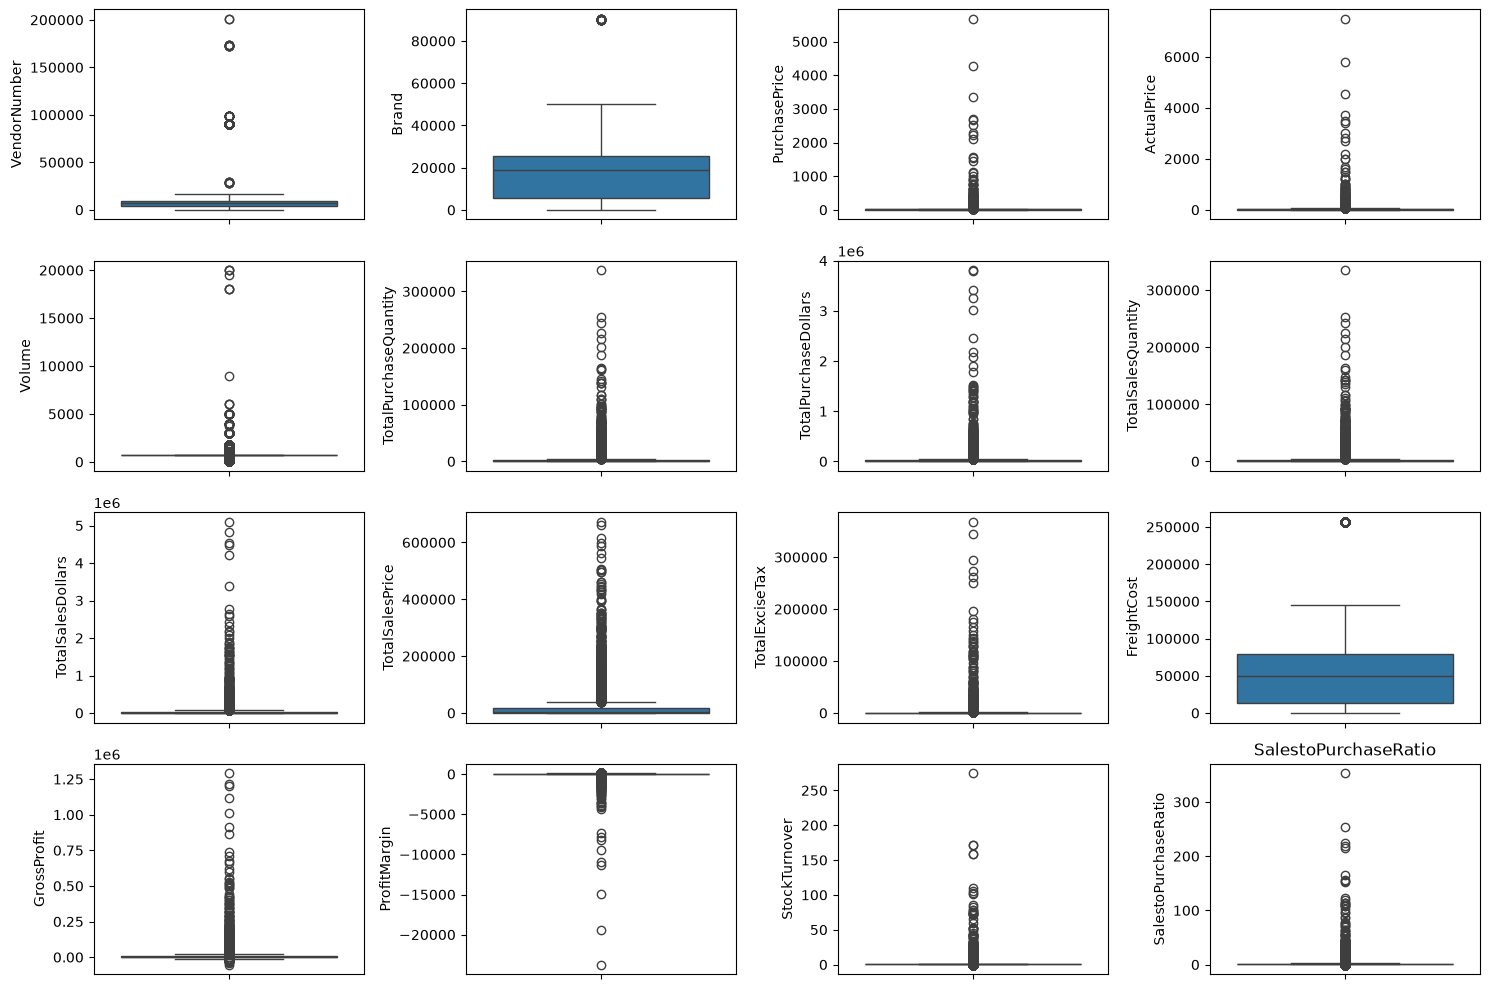

In [7]:
# Outlier Detection with Boxplots

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
        plt.subplot(4, 4, i+1)
        sns.boxplot(y=df [col])
plt.title(col)
plt.tight_layout()
plt.show()

In [8]:
df = pd.read_sql_query ("""SELECT *
FROM vendor_sales_summary
Where GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""",conn)

In [9]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8603,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8604,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8605,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8606,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


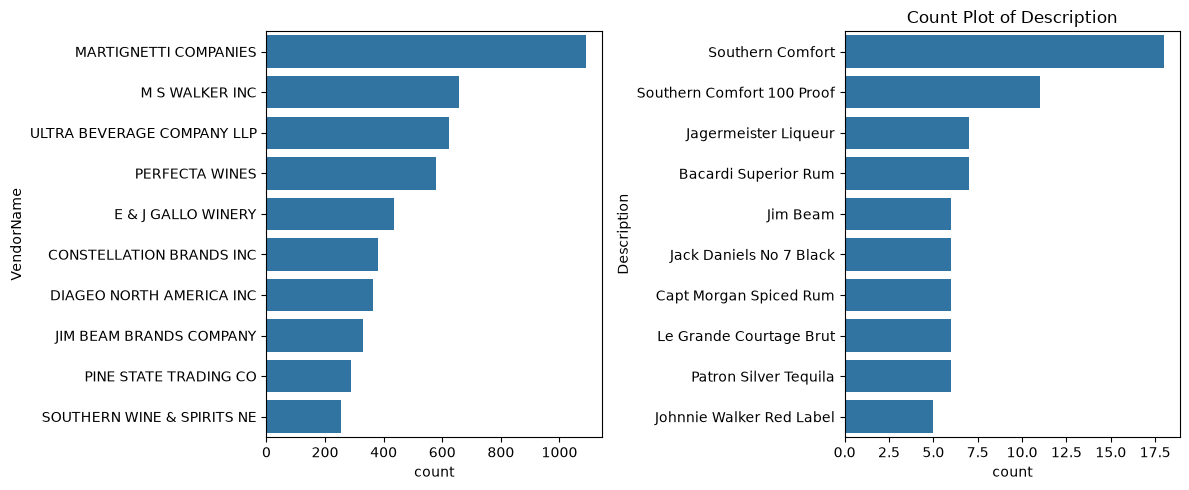

In [10]:
# Count Plots for Categorical Columns

categorical_cols = ["VendorName", "Description"]
plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols):
  plt.subplot(1, 2, i+1)
  sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) # Top 10 categories
plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

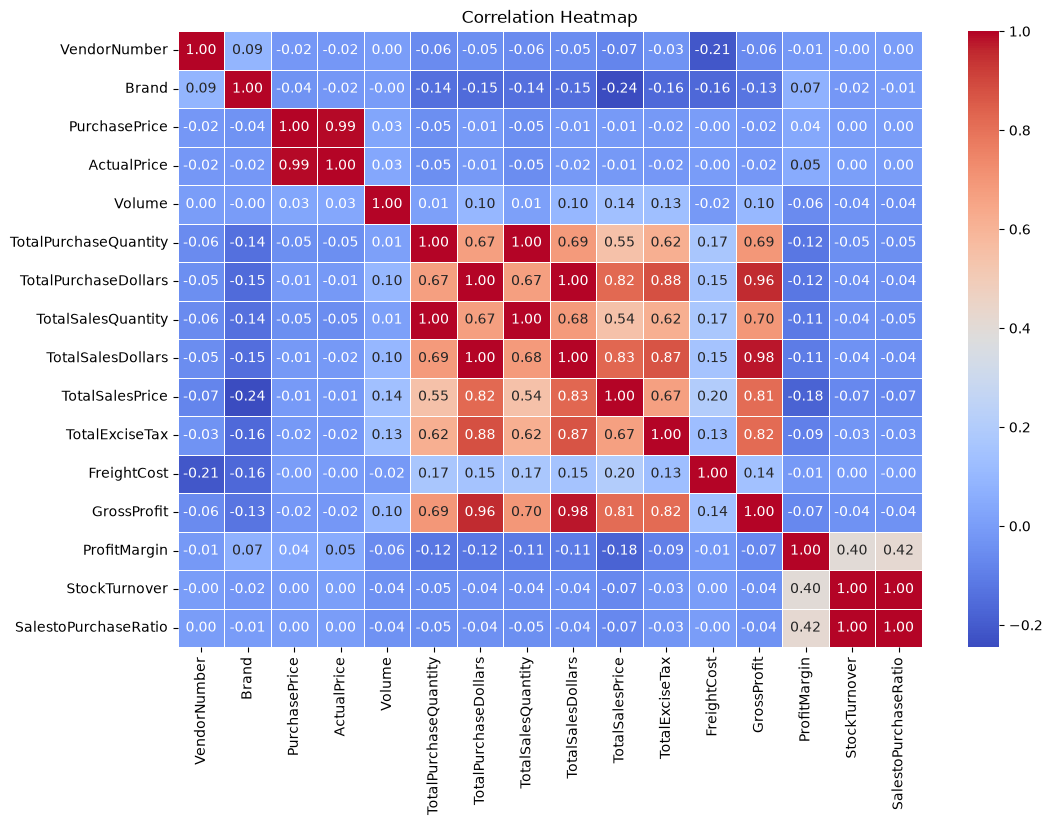

In [11]:
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [13]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [14]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [15]:
low_sales_threshold

np.float64(560.652)

In [16]:
high_margin_threshold

np.float64(64.97017552750111)

In [17]:
target_brands = brand_performance[
(brand_performance ['TotalSalesDollars'] <= low_sales_threshold) &
(brand_performance ['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [18]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000]

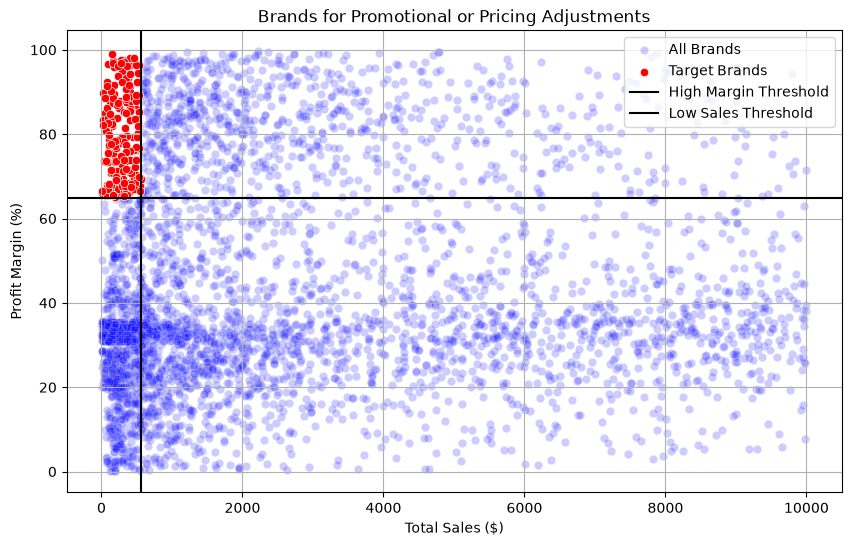

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color= "red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='-', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='-', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [21]:
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors


VendorName
DIAGEO NORTH AMERICA INC      6.799010e+07
MARTIGNETTI COMPANIES         3.944209e+07
PERNOD RICARD USA             3.206320e+07
JIM BEAM BRANDS COMPANY       3.142302e+07
BACARDI USA INC               2.485482e+07
CONSTELLATION BRANDS INC      2.421875e+07
BROWN-FORMAN CORP             1.910928e+07
E & J GALLO WINERY            1.839990e+07
ULTRA BEVERAGE COMPANY LLP    1.653210e+07
M S WALKER INC                1.472994e+07
Name: TotalSalesDollars, dtype: float64

In [22]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [23]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

In [24]:
print(type(top_vendors))
print(top_vendors.head)

<class 'pandas.core.series.Series'>
<bound method NDFrame.head of VendorName
DIAGEO NORTH AMERICA INC      6.799010e+07
MARTIGNETTI COMPANIES         3.944209e+07
PERNOD RICARD USA             3.206320e+07
JIM BEAM BRANDS COMPANY       3.142302e+07
BACARDI USA INC               2.485482e+07
CONSTELLATION BRANDS INC      2.421875e+07
BROWN-FORMAN CORP             1.910928e+07
E & J GALLO WINERY            1.839990e+07
ULTRA BEVERAGE COMPANY LLP    1.653210e+07
M S WALKER INC                1.472994e+07
Name: TotalSalesDollars, dtype: float64>


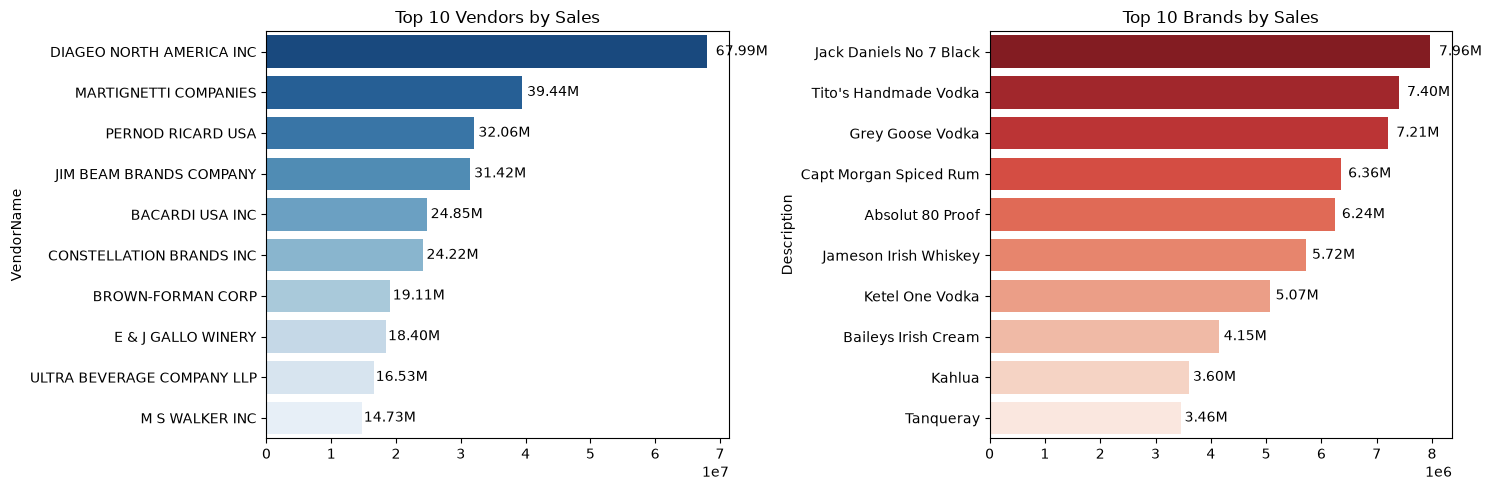

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# Top 10 Vendors
plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Blues_r"
)

plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
      bar.get_width() + (bar.get_width() * 0.02),
      bar.get_y() + bar.get_height() / 2,
      format_dollars(bar.get_width()),
      ha="left",
      va="center",
      fontsize=10,
      color="black"
    )

# Top 10 Brands
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)

plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black"
    )

plt.tight_layout()
plt.show()

In [26]:
df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
})

,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
VendorName,,,
ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...
WEIN BAUER INC,42694.64,13522.49,56217.13
WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20


In [27]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape

(119, 4)

In [28]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [29]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending=False),2)

In [30]:
top_vendors = vendor_performance.head(10)
top_vendors ['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors ['TotalPurchaseDollars'] =top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors ['GrossProfit'] =top_vendors['GrossProfit'].apply(format_dollars)
top_vendors



,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.23
57,MARTIGNETTI COMPANIES,25.56M,13.88M,39.44M,8.28
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.73
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.61
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.65
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.95
11,BROWN-FORMAN CORP,13.78M,5.33M,19.11M,4.47
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.91
106,ULTRA BEVERAGE COMPANY LLP,11.19M,5.34M,16.53M,3.63
79,SAZERAC CO INC,10.26M,3.49M,13.75M,3.33


In [31]:
top_vendors['PurchaseContribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.23
57,MARTIGNETTI COMPANIES,25.56M,13.88M,39.44M,24.51
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,32.24
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,39.85
6,BACARDI USA INC,17.43M,7.42M,24.85M,45.50
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,50.45
11,BROWN-FORMAN CORP,13.78M,5.33M,19.11M,54.92
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,58.83
106,ULTRA BEVERAGE COMPANY LLP,11.19M,5.34M,16.53M,62.46
79,SAZERAC CO INC,10.26M,3.49M,13.75M,65.79


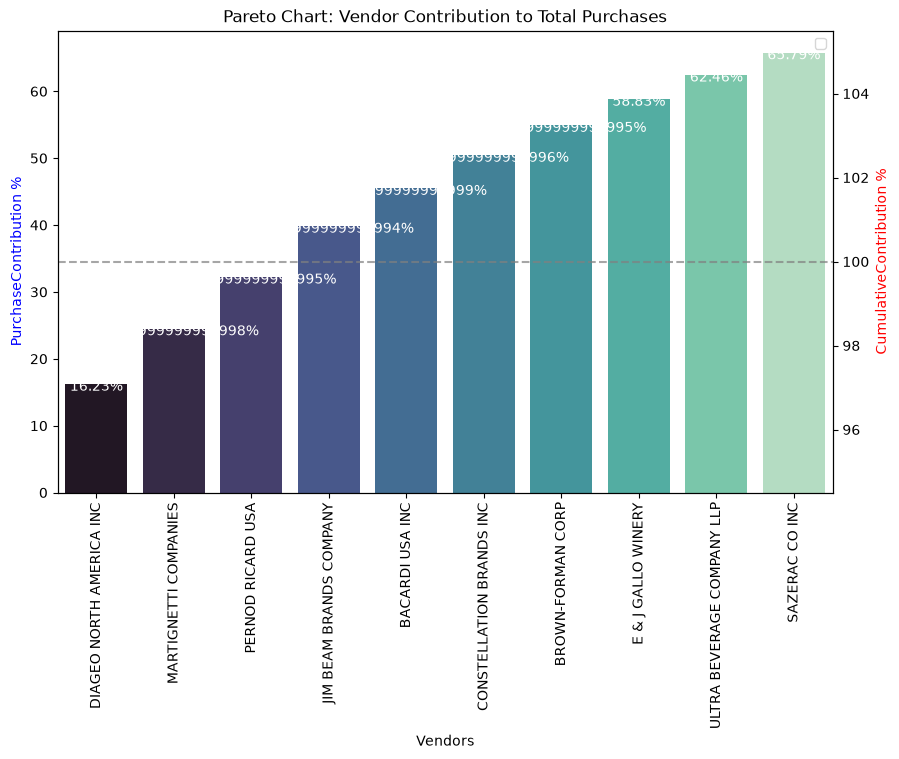

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(x= top_vendors ['VendorName'], y= top_vendors ['PurchaseContribution%'], palette="mako", ax=ax1)
for i, value in enumerate(top_vendors ['PurchaseContribution%']): 
 ax1.text(i, value-1, str(value) +'%', ha='center', fontsize=10, color='white')
ax2 = ax1.twinx()

ax1.set_xticklabels (top_vendors ['VendorName'], rotation=90)
ax1.set_ylabel('PurchaseContribution %', color='blue')
ax2.set_ylabel('CumulativeContribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')
ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2. legend (loc='upper right')

plt.show()

In [33]:
print(f"Total PurchaseContribution% of Top 10 Vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%")

Total PurchaseContribution% of Top 10 Vendors is 450.78%


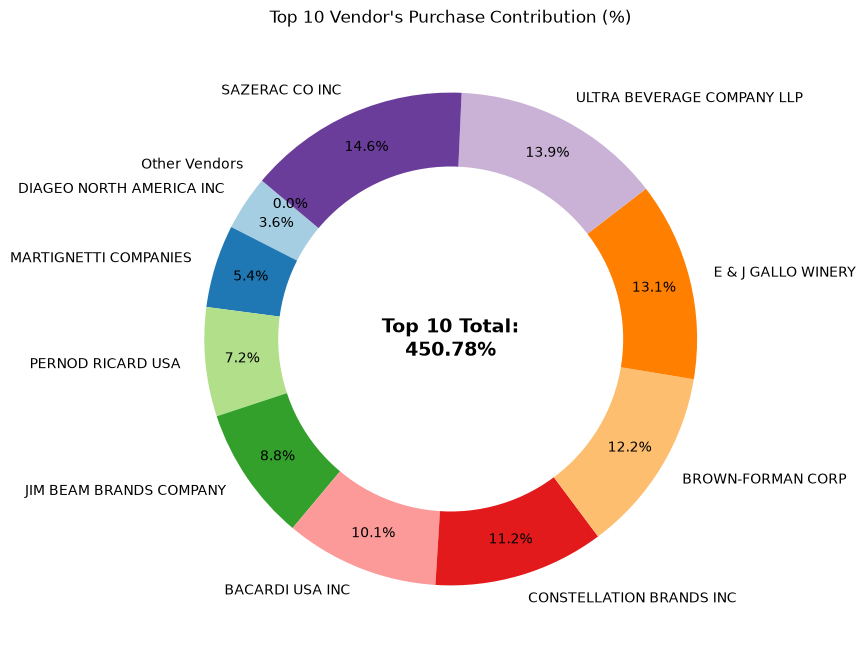

In [34]:
import matplotlib.pyplot as plt

vendors = list(top_vendors ['VendorName'].values)
purchase_contributions = list(top_vendors ['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = max(0,100-total_contribution)

vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)
fig, ax =plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors,autopct='%1.1f%%',startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')
plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

In [35]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [36]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small","Medium","Large"])

In [37]:
df.groupby('OrderSize')[['TotalPurchaseQuantity']].mean()

,TotalPurchaseQuantity
OrderSize,
Small,27.345404
Medium,552.101500
Large,10721.877658


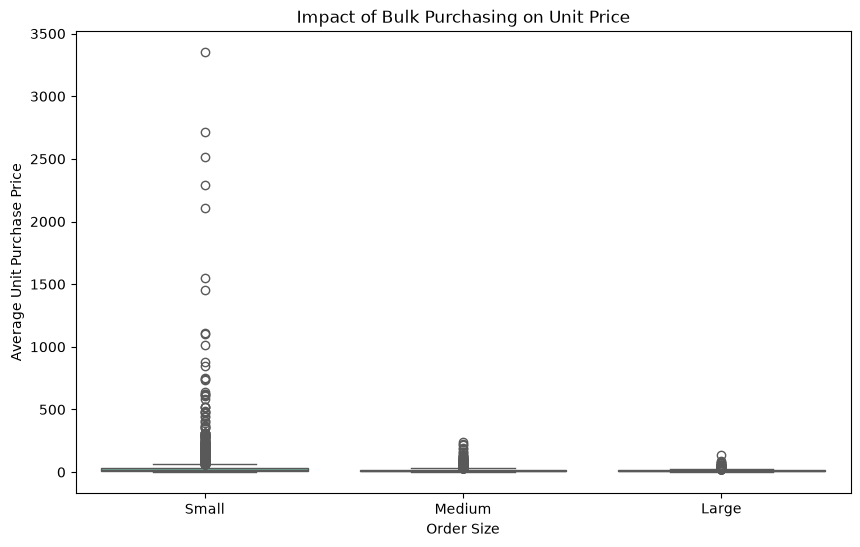

In [38]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="OrderSize",y="UnitPurchasePrice",palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

In [39]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending = True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
PARK STREET IMPORTS LLC,0.699412
HIGHLAND WINE MERCHANTS LLC,0.708333
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


In [40]:
df ["UnsoldInventoryValue"] = (df ["TotalPurchaseQuantity"]- df ["TotalSalesQuantity"]) * df ["PurchasePrice"]

print('Total Unsold Capital:', format_dollars (df ["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 2.68M


In [41]:
inventory_value_per_vendor = df.groupby("VendorName") ["UnsoldInventoryValue"].sum().reset_index()

inventory_value_per_vendor = inventory_value_per_vendor.sort_values (by="UnsoldInventoryValue", ascending=False)

inventory_value_per_vendor ['UnsoldInventoryValue'] = inventory_value_per_vendor ['UnsoldInventoryValue'].apply(format_dollars)

inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
79,SAZERAC CO INC,296.95K
30,E & J GALLO WINERY,228.28K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K
54,MAJESTIC FINE WINES,114.46K


In [48]:
top_threshold = df ["TotalSalesDollars"].quantile(0.75)



In [49]:
low_threshold = df ["TotalSalesDollars"].quantile(0.25)


In [50]:
top_vendors = df [df ["TotalSalesDollars"] >= top_threshold] ["ProfitMargin"].dropna()



In [51]:
low_vendors = df [df ["TotalSalesDollars"] <= low_threshold] ["ProfitMargin"].dropna()

In [44]:
def confidence_interval(data, confidence=0.95):

    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) -1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.62), Mean: 31.18
Low Vendors 95% CI: (40.53, 42.67), Mean: 41.60


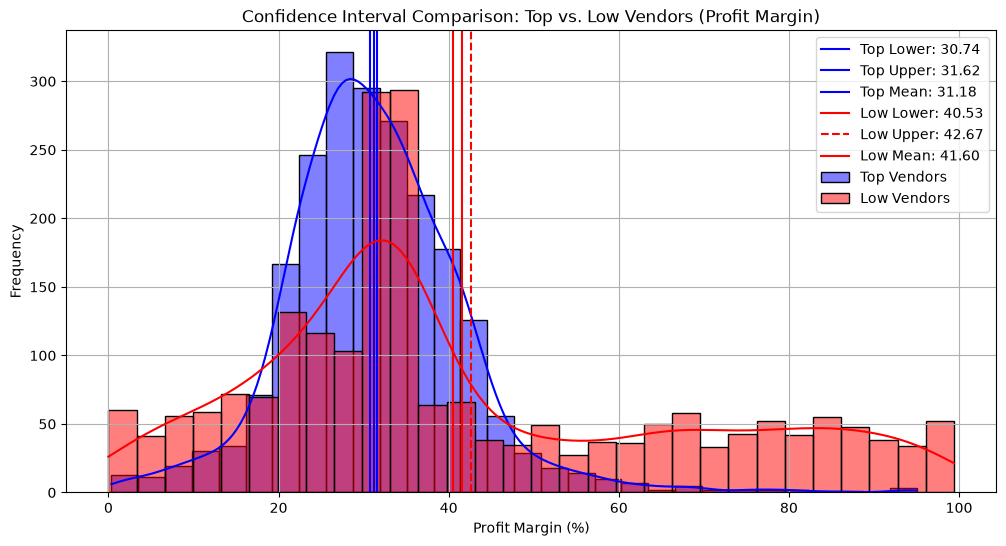

In [52]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)

low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print (f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")

print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

#Top Vendors Plot

sns.histplot(top_vendors, kde =True, color="blue", bins =30, alpha=0.5, label="Top Vendors")

plt.axvline(top_lower, color="blue", linestyle="-", label=f"Top Lower: {top_lower:.2f}")

plt.axvline(top_upper, color="blue", linestyle="-", label=f"Top Upper: {top_upper:.2f}")

plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot

sns.histplot(low_vendors, kde =True, color="red", bins =30, alpha=0.5, label="Low Vendors")

plt.axvline(low_lower, color="red", linestyle="-", label=f"Low Lower: {low_lower:.2f}")

plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")

plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

#Finalize Plot

plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")

plt.xlabel("Profit Margin (%)")

plt.ylabel("Frequency")

plt.legend()

plt.grid(True)

plt.show()

In [53]:
top_threshold = df ["TotalSalesDollars"].quantile(0.75)

low_threshold = df ["TotalSalesDollars"].quantile(0.25)

top_vendors = df [df ["TotalSalesDollars"] >= top_threshold] ["ProfitMargin"].dropna()

low_vendors = df [df ["TotalSalesDollars"] <= low_threshold] ["ProfitMargin"].dropna()

#Perform Two-Sample T-Test

t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

#Print results

print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
   print("Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.")
else:  
   print("Fail to Reject Ho: No significant difference in profit margins.")

T-Statistic: -17.7331, P-Value: 0.0000
Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.


In [55]:
%whos

Variable                     Type          Data/Info
----------------------------------------------------
autotexts                    list          n=11
ax                           Axes          Axes(0.1275,0.11;0.77x0.77)
ax1                          Axes          Axes(0.125,0.11;0.775x0.77)
ax2                          Axes          Axes(0.125,0.11;0.775x0.77)
bar                          Rectangle     Rectangle(xy=(0, 8.6), wi<...>+06, height=0.8, angle=0)
brand_performance            DataFrame     Shape: (4160, 3)
categorical_cols             list          n=2
centre_circle                Circle        Circle(xy=(0, 0), radius=0.7)
col                          str           Description
confidence_interval          function      <function confidence_inte<...>al at 0x000001EB1E704A40>
conn                         Connection    <sqlite3.Connection object at 0x000001EB0239F970>
correlation_matrix           DataFrame     Shape: (16, 16)
df                           DataFrame     Shape

In [56]:
print(brand_performance.head())
print(vendor_performance.head())
print(inventory_value_per_vendor.head())

                    Description  TotalSalesDollars  ProfitMargin
1       .nparalleled Svgn Blanc            1094.63     29.978166
2           10 Span Cab Svgn CC            2703.89     20.937612
3              10 Span Chard CC            3325.56     27.806445
4  10 Span Pnt Gris Monterey Cy            2082.22     32.226182
5             10 Span Pnt Nr CC            2441.74     25.836084
                  VendorName  TotalPurchaseDollars  GrossProfit  \
25  DIAGEO NORTH AMERICA INC           50097226.16  17892873.26   
57     MARTIGNETTI COMPANIES           25562503.46  13879581.64   
68         PERNOD RICARD USA           23851164.17   8212032.02   
46   JIM BEAM BRANDS COMPANY           23494304.32   7928716.14   
6            BACARDI USA INC           17432020.26   7422796.88   

    TotalSalesDollars  PurchaseContribution%  
25        67990099.42                  16.23  
57        39442085.10                   8.28  
68        32063196.19                   7.73  
46        31423020.

In [60]:
brand_performance.to_csv("Brand_Performance.csv", index=False)


In [61]:
top_vendors.to_csv("Purchase_Contribution.csv", index=False)

In [62]:
low_turnover = vendor_sales_summary[
    vendor_sales_summary["StockTurnover"] < 1
]

low_turnover.to_csv("Low_Turnover.csv", index=False)

NameError: name 'vendor_sales_summary' is not defined

In [ ]:
low_turnover.to_csv("Low_Turnover.csv",index=False)